# Homework 2

## Essential Information

* Deadline: Friday March 21st (11:59 PM)
* Independent Assignment: This assignment should be done independently
    * Sharing of solutions is not allowed
    * Discussing _approaches_ is discouraged. If this occurs please cite who you discussed with. I want you thinking through how to solve this problem on your own.
    * Collaborative support with the practicalities of coding (I.E. helping someone with pandas or the google colab environment) is encouraged and fine.

## Overview

This assignment has you building python code for a selection of real recommendation algorithms. This code will not necissarily be _optimized_ but it should allow you to practice with these algorithms in a more realistic way. You may think that this is _unnecissary_, but practical experiance shows that this is the best way to ensure you really understand all the many little details that goes into these algorithms. By doing this assignment you will

* Build your first practical recommendatino algorithm
* Develop an understanding of the _structure_ and _details_ of practical recommender systems code.
* Perform your first basic recommender system evaluation.

## Outline

I've broken down this assignment into four parts

1. (~10 points) A basic User-Item average algorithm.
2. (~25 points) A User-User algorithm
3. (~25 points) An Item-Item algorithm
4. (~40 points) A basic evaluation


## Notes:
 * All instructions are in-line in this document. We've tried to balance clarity with brevity here, which means that there might be a few instructions that we're _assuming_ are clear enough. If you're ever unclear what is expected or required of you please reach out over slack or email for clarification.
 * As _this_ document will be hard to meaningfully update after the assignment begins, make sure you regularly check canvas and slack for any updates, new hints or FAQs
 * While data will be passed into your code in pandas format typically, you will probably not be able to build these algorithms "only in pandas" -- you may need to implement code with real and classic data structures.
 * We will use a subset of the MovieLens dataset for this assignment. This will speed up the work drastically, but will definitely skew the results as our subsample is going to be much denser than a normal dataset.

# How to get started and what to submit

To start this assignment, make a copy of this notebook: <https://colab.research.google.com/drive/1zK1_HQJ4HEkfxnaZPicdqGIAh2YJ8N-Y?usp=sharing>

by clicking File --> save a copy in Drive like below. Then please work on your copy.

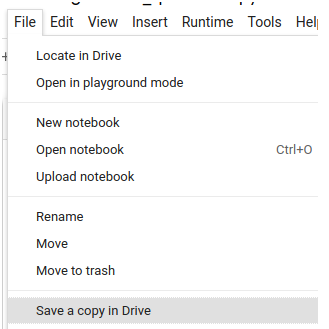

You will need to submit the EDITOR link of your notebook on Canvas (click share --> get link --> editor --> copy link).

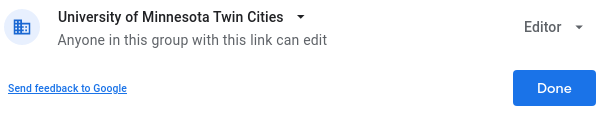



In [ ]:
!pip uninstall numpy -y
!pip install numpy==1.26.0

Found existing installation: numpy 1.26.0
Uninstalling numpy-1.26.0:
  Successfully uninstalled numpy-1.26.0
  Using cached numpy-1.26.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (58 kB)
Using cached numpy-1.26.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)


In [ ]:
import random
import numpy as np
import pandas as pd

my_seed = 2025
random.seed(my_seed)
np.random.seed(my_seed)

In [ ]:

# install surprise -- this takes a minute or so... we might not end up using this framework very much, but it's nice to have a _reall_ tookit
!pip install surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 2.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp311-cp311-linux_x86_64.whl size=2505228 sha256=bf08afb6f85330ba19eb17deeda42ef4e776d109d381192c2ae8ce8a71c12c7f
  Stored in directory: /root/.cache/pip/wheels/2a/8f/6e/7e2899163e2d85d8266daab4aa1cdabec7a6c56f83c015b5af
Successfully built scikit-surprise


In [ ]:
 # use surprise to download the ml-1m dataset (https://grouplens.org/datasets/movielens/1m/). Please input "Y" when being asked "Do you want to download it".
from surprise import Dataset

data = Dataset.load_builtin('ml-1m')

Dataset ml-1m could not be found. Do you want to download it? [Y/n] Yes
Trying to download dataset from https://files.grouplens.org/datasets/movielens/ml-1m.zip...
Done! Dataset ml-1m has been saved to /root/.surprise_data/ml-1m


In [ ]:
# Pre-processing step -- filter down to the N most popular users and M most popular items. This will DEFINTIELY skew our end-results since these are the "easy" items and "easy" users to recommend for.
N_ITEMS = 1164
N_USERS = 1812
# These numbers were chosen to keep the ratio of items to users about the same.


# first filter to the popular items
ratings_df = pd.DataFrame(data.raw_ratings, columns=["userId", "movieId", "rating", "tstamp"])
rating_count_by_item = ratings_df.groupby("movieId")["rating"].count()
rating_count_by_item = rating_count_by_item.sort_values(ascending=False)
ITEMS = rating_count_by_item.index[:N_ITEMS]
ratings_df = ratings_df[ratings_df['movieId'].isin(ITEMS)]

# then filter to the active users
rating_count_by_user = ratings_df.groupby("userId")["rating"].count()
rating_count_by_user = rating_count_by_user.sort_values(ascending=False)
USERS = rating_count_by_user.index[:N_USERS]
ratings_df = ratings_df[ratings_df['userId'].isin(USERS)]

# Finally, convert to a matrix structure.
rating_matrix = ratings_df.pivot(index='userId', columns='movieId', values='rating')

# # just for sorting the rows/columns as they were alphabetical before
rating_matrix = rating_matrix.reindex(sorted(rating_matrix.index, key=int), axis=0)
rating_matrix = rating_matrix.reindex(sorted(rating_matrix.columns, key=int), axis=1)

# # user x movie
display(rating_matrix)

movieId,1,2,3,5,6,7,10,11,16,17,...,3873,3893,3897,3911,3916,3917,3927,3948,3949,3952
userId,,,,,,,,,,,,,,,,,,,,,
10,5.0,5.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN
15,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN
17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN
18,4.0,2.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,4.0,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
19,5.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6025,5.0,NaN,3.0,NaN,NaN,4.0,NaN,4.0,NaN,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6035,4.0,NaN,1.0,1.0,NaN,3.0,NaN,4.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6036,NaN,NaN,NaN,NaN,3.0,NaN,NaN,3.0,3.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Algorithm 1: User-Item Average.

This algorithm is _barely_ a personalized algorithm -- while it does make different predictions for each user, it will ultimatley provide the same recommendation to every user. The prediction equation for this algorithm is as follows:

$\hat{r_{ui}} = \mu_i + \mu_u$

In otherwords -- to predict for user $u$ and item $i$ we add an item-score and a user-score. These two scores can be computed MANY ways, but the most common is a two-pass algorithm:

1. Given the list of training ratings...
2. compute the average rating across all items and users
3. compute a damped item-average for each item. (use a damping factor of 5 and damp the averages to the global mean) -- these values are $\mu_i$
4. substract the average item ratings from the observed ratings
5. With these modified ratings compute the user-average rating for each user (again damped, in this case damp the ratings towards 0, and use a damping factor of 5 again) -- these are the $\mu_u$ values, They are an estimate of how much a user tends to rate above, or below, the average for the items they have rated.

In [ ]:
class UserItemBaseline:
  def __init__(self, damping_factor=5):
    self.damping_factor = damping_factor
    self.mu_i = {}     # dampened item means
    self.mu_u = {}     # user tendency
    self.mu = 0        # global rating mean

  def train(self, ratings_df):
    # Fill in mu_u and mu_i using the above equation
    self.ratings = ratings_df
    self.mu = ratings_df.stack().mean()

    item_sums = ratings_df.sum()  # Sum ratings across users for each item
    item_counts = ratings_df.count()  # Count ratings for each item
    damped_item_means = (item_sums + self.damping_factor * self.mu) / (item_counts + self.damping_factor)
    self.mu_i = damped_item_means.to_dict()

    ratings_corrected = ratings_df - self.mu
    user_sums = ratings_corrected.sum(axis=1)  # Sum across items for each user
    user_counts = ratings_corrected.count(axis=1)  # Count ratings for each user
    damped_user_means = (user_sums) / (user_counts + self.damping_factor)
    self.mu_u = damped_user_means.to_dict()

  def predict(self, userId, itemId):
    # create a prediction for a given user and item
    return self.mu_i.get(itemId, self.mu) + self.mu_u.get(userId, 0)

  def predict_all(self, userId, items):
    # There might be a better way to do this, and you're free to find it.
    # but this _should_ be good enough for quick experimental use
    predictions = []
    for item_id in items:
      predictions.append({
          "userId": userId,
          "movieId": item_id,
          "prediction": self.predict(userId, item_id)
      })
    return pd.DataFrame(predictions)



In [ ]:
# Build a baseline model.
baseline = UserItemBaseline()
baseline.train(rating_matrix)

## Part 1 Questions


In [ ]:
# What would we predict for user 175 and item 1 using this baseline model.
display(baseline.predict(175,1))

3.625873303184187

In [ ]:
# What are the users with the top-5 and bottom-5 values for mu_u? What are those values?
mu_u = pd.Series(baseline.mu_u).sort_values()
display(mu_u)
# These values describe user rating tendencies against an item's mean
# Positive values indicate a user typically rating values above the mean
# Negative values indicate a user typically rating values below the mean

,0
5686,-1.455125
5039,-1.291866
3209,-1.269759
1434,-1.262035
1340,-1.226646
...,...
4904,0.952830
5862,0.977051
4086,1.002885
953,1.075500


# Algorithm 2: User-User Collaborative Filtering

For this part you should implement a user-user collaborative filtering algorithm The constructor for this object takes an n_neighbors parameter that sets how many neighbors the algorithm wants to use when making a prediction.

Normally would would pre-compute the similarity model for a user-user collaborative filtering algorithm, as it tends to change a lot, but for simplicty, we recommend doing so here. Like the previous algorithm object we've broken the code down to two parts:

## Train
This takes the ratings (your choice -- either the ratings data frame or a ratings matrix) and should 1) store the ratings for future use, 2) compute the user-user similarity matrix using pearson similarity.  3) compute the user average ratings (so we can use a weighted average that is normalized by user-average-rating like we saw in lecture)

## Predict
This takes a user_id and an item_id and:

1. Figure out what users have rated this item
2. computes the neighbors  of the user as the `n_neighbors` most similar other users who have rated this item. ($N_u$)
3. Computes the prediction using the equation from class: $$\hat{r}_{uj} = \mu_u + \frac{\sum_{v \in N_u}S_{uv}(r_{vj} - \mu_v)}{\sum_{v \in N_u} S_{uv}}$$

In [ ]:
class UserUserCF:
  # take in number of neighbors we want to use
  def __init__(self, n_neighbors=5):
    self.n_neighbors = n_neighbors
    self.ratings = None
    self.similarity = None
    self.user_averages = None

  def train(self, ratings_matrix):
    self.ratings = ratings_matrix
    # compute the similarity matrix.
    self.similarity = ratings_matrix.T.corr(method='pearson')
    self.user_averages = self.ratings.mean(axis=1)

  # get predicted ratings for a user
  def predict(self, user_id, item_id):
    # Compute the neighborhood of other users for this specific prediction
    mask = self.ratings[str(item_id)].notna()
    neighbors = self.similarity[str(user_id)].sort_values(ascending=False)
    filtered_neighbors = neighbors[mask]
    top_neighbors = filtered_neighbors.iloc[1:self.n_neighbors+1]
    # Compute the prediction
    mu_u = self.user_averages[str(user_id)]
    numerator = 0
    denominator = 0
    for v in top_neighbors.index:
      mu_v = self.user_averages[str(v)]       # average rating for user v
      r_vi = self.ratings[str(item_id)][v]    # user v's rating for the given item
      s_uv = self.similarity[str(user_id)][v] # similarity between given user and user v
      numerator += s_uv * (r_vi - mu_v)
      denominator += abs(s_uv)
    return mu_u + numerator / denominator

  def predict_all(self, user_id, items):
    # return a data frame with columns userId, movieId prediction, with one row for each item in items.
    predictions = []
    for item_id in items:
      predictions.append({
          "userId": user_id,
          "movieId": item_id,
          # "movieTitle":
          "prediction": self.predict(user_id, item_id)
      })
    return pd.DataFrame(predictions)

In [ ]:
# Build and train a user-user model
user_user = UserUserCF(10)
user_user.train(rating_matrix)

## Part 2 Questions
We will use the following questions to help check if the work is done well, and as diagnostic questions you can use to see if your anwers are in the range of "reasonable"

In [ ]:
# What are the top-10 predictions for user 549? (please include movieId and movie titles in answer)
ans1 = user_user.predict_all('549', ITEMS)
display(ans1.sort_values(by=['prediction'], ascending=False).head(10))

,userId,movieId,prediction
90,549,750,5.631053
124,549,1206,5.475605
672,549,922,5.448929
35,549,541,5.391475
599,549,1248,5.390948
557,549,3435,5.361777
342,549,1267,5.348300
12,549,608,5.331209
161,549,3160,5.283532
160,549,923,5.273419


In [ ]:
# What are the two most similar users?
similarities = {}
for u in range(0, N_USERS - 1):
  user_u = user_user.similarity.index[u]
  for v in range(u + 1, N_USERS):
    user_v = user_user.similarity.index[v]
    similarities[(user_u, user_v)] = user_user.similarity[str(user_u)][str(user_v)]
sorted_similarities = dict(sorted(similarities.items(), key=lambda item: item[1], reverse=True))
top_similarity = next(iter(sorted_similarities.items()))
display(top_similarity)
# The two most similar users are users 1001 and 2348

(('1001', '2348'), 1.0)

In [ ]:
# How many user-pairs have negative similarity?
negative_similarity = {key: val for key, val in similarities.items() if val < 0}
display(len(negative_similarity))
# There are 213766 user-pairs with negative similarity

213766

# Algorithm 3: Item-Item Collaborative Filtering
For this part you should implement the Item-Item collaborative filtering algorithm. Because this algorithm often is deployed with a pre-computed and truncated similarity model, we'll do the same here.

The constructor takes parameters:

* `model_size` -- When training the algorithm, how many possible neighbors to keep for each item? (keep the top `model_size` most similar items when training the model)
* `neighborhood_size` -- How many neighbors to use when actually predicting.


## Train
This takes the ratings (your choice -- either the ratings data frame or a ratings matrix) and should

1. store the ratings for future use.
2. Compute user-average ratings for the next step.
3. compute the item-item similarity matrix using adjusted cosine similarity. $$S_{ik} = \frac{ \sum_{u \in U_i \cap U_k} (r_{ui}-\mu_u)(r_{uk}-\mu_u)}{\sqrt{\sum_{u \in U_i \cap U_k} (r_{ui}-\mu_u)^2} \sqrt{\sum_{u \in U_i \cap U_k} (r_{uk}-\mu_u)^2}}$$  
4. create the "truncated model" for item-item. As a reminder we store this instead of a compelte item-item similarty matrix. You can choose how best to store this, but it should contain only `model_size` most similar items for each item (as well as their similarity scores)

## Predict
This takes a user_id and an item_id and:

1. Figures out which items the user has rated
2. Computes the neighborhood of the item-to-predict as the `neighborhood_size` most similar previously rated items.
3. Computes the prediction using the equation from class: $$\hat{r}_{ui} = \frac{\sum_{k \in I_u \cap N_i}S_{ik}r_{uk}}{\sum_{k \in I_u \cap N_i}|S_{ik}|}$$

## Some hints:

Efficient computation of the item-item similarit matrix is important -- but tricky. We've downsized the dataset so a less efficient loop-based solution will probably be fine. Try to begin by coding something you're positive (and can confirm) is correct -- then loop back and make it faster while keeping the "obviously correct" code around so you can confirm your results are the same.


In [ ]:
class ItemItemCF:
  # take in number of neighbors we want to use
  def __init__(self, model_size = 100, neighborhood_size=5):
    self.model_size = model_size
    self.neighborhood_size = neighborhood_size
    self.ratings = None
    # Other parameters you want to store from training for use in predict will want to be defined here.
    self.similarity = None
    self.models = {} # maps item ids to respective offline model

  def train(self, ratings_matrix):
    #Subtraction not lining up correctly? Pearson value incorrect? Get a similarity matrix more accurate!

    self.ratings = ratings_matrix
    # compute the similarity matrix.
    ratings_centered = ratings_matrix.sub(ratings_matrix.mean(axis=1), axis=0)
    self.similarity = ratings_centered.corr(method='pearson')


    # compute truncated model for each item i
    for item in self.similarity.iterrows():
      item_id = item[0]
      sorted_neighbors = item[1].sort_values(ascending=False)
      top_neighbors = sorted_neighbors.iloc[1:self.model_size+1].index
      self.models.update({item_id: self.similarity.loc[top_neighbors][item_id]})

  # get predicted ratings for a user
  def predict(self, user_id, item_id):
    # Compute the neighborhood of other users for this specific prediction
    mask = self.ratings.loc[str(user_id)].notna()
    neighbors = self.models[str(item_id)].sort_values(ascending=False)
    filtered_neighbors = neighbors[mask]
    neighborhood = filtered_neighbors.iloc[1:self.neighborhood_size+1]

    # Compute the prediction
    numerator = 0
    denominator = 0
    for k in neighborhood.index:
      r_uk = self.ratings.loc[str(user_id), str(k)]
      s_ik = neighborhood[k]
      numerator += s_ik * r_uk
      denominator += abs(s_ik)

    if denominator == 0:
      return 0
    return numerator / denominator

  def predict_all(self, user_id, items):
    # return a data frame with columns userId, movieId prediction, with one row for each item in items.
    predictions = []
    for item_id in items:
      predictions.append({
          "userId": user_id,
          "movieId": item_id,
          # "movieTitle":
          "prediction": self.predict(user_id, item_id)
      })
    return pd.DataFrame(predictions)



In [ ]:
item_item = ItemItemCF(100,10)
item_item.train(rating_matrix)

## Part 3 Questions
Again -- we're using these questions both as a way to encourage you to check intermediary results for seeming _reasonable_ and a quick way for us to check if your results match those produced by any common solutions.

In [ ]:
# What are the 100 most similar items to "Dracula: Dead and Loving It" (movieId 12) and what are their similarity scores?
item_id = 16
num = 100
item_item.similarity[str(item_id)].sort_values(ascending=False)[1:num+1]
# The topmost similar item to movie 16 was movie 2301 with a score of approximately 0.39
# Least similar item in the top list of 100 items is movie 1221 with a score of approximately 0.16

,16
movieId,
2301,0.393852
1213,0.339339
2109,0.320645
2883,0.303708
2318,0.292923
...,...
1921,0.166397
1266,0.165854
1673,0.165650


In [ ]:
# What does Item-Item predict for user 175 and movieId 1 (toy story)
item_item.predict(175,1)
# item_item predicts a rating of approximately 3.99 for user 175 and movie 1

3.9940748683665412

In [ ]:
# What are user 175's top-10 highest predicted items?
item_item.predict_all(175, ITEMS).sort_values(by=['prediction'], ascending=False).head(10)

,userId,movieId,prediction
9,175,593,4.818713
76,175,1394,4.801040
248,175,1199,4.794654
371,175,953,4.752061
995,175,2318,4.726812
673,175,345,4.716433
0,175,2858,4.712247
18,175,1617,4.710054
643,175,1212,4.708698
1132,175,1057,4.699716


# Part 4 -- A basic evaluation

For this part we are going to perform a basic evaluation, or rather, 2 basic evaluations (which you will then be tasked with comparing).

## Evaluation 1:
This should be simple -- using the algorithm objects you trained earlier in this assignment -- simply get a prediction to match with each rating. Them compute the RMSE for each algorithm.

## Evalution 2:
This will be a bit more elegant -- you should randomly sample 10% of the ratings as test ratings, keeping the remaining 90% as training ratings. You should then train new algorithm objects on the 90% training ratings. Then you can follow the same protocol as above -- get predictions for the 10% of testing ratings from each algorithm and compute an RMSE score for each algorithm.

In [ ]:
# Code for evaluation 1 here.

## Part 1 -- getting predictions for each rating in the original dataset.
def predict_all_ratings(model, matrix_to_predict):
  predictions = {}

  for item_index in matrix_to_predict.columns:
    valid_indices = matrix_to_predict[item_index][matrix_to_predict[item_index].notnull()].index
    for user_index in valid_indices:
      actual = matrix_to_predict.loc[str(user_index), str(item_index)]
      prediction = model.predict(user_index, item_index)

      predictions[(user_index, item_index)] = prediction

  row_indices = sorted(list(set([k[0] for k in predictions.keys()])))
  col_indices = sorted(list(set([k[1] for k in predictions.keys()])))

  predictions_df = pd.DataFrame(index=row_indices, columns=col_indices)

  for (row, col), value in predictions.items():
    predictions_df.loc[row, col] = value

  return predictions_df


prediction_df_user_item = predict_all_ratings(baseline, rating_matrix)
prediction_df_user_user = predict_all_ratings(user_user, rating_matrix)
prediction_df_item_item = predict_all_ratings(item_item, rating_matrix)

In [ ]:
## Part 2 -- merge with the rating data
difference_df_user_item = prediction_df_user_item.sub(rating_matrix, axis=0)
difference_df_user_user = prediction_df_user_user.sub(rating_matrix, axis=0)
difference_df_item_item = prediction_df_item_item.sub(rating_matrix, axis=0)

In [ ]:
## Part 3 -- compute RMSE for each algorithm
def calculate_rmse(difference_df):
  squared_errors = difference_df.apply(lambda x: x ** 2)
  error_count = difference_df.notna().sum().sum()
  numerator = squared_errors.sum().sum()
  denominator = error_count
  return (numerator / denominator) ** 0.5


user_item_rmse = calculate_rmse(difference_df_user_item)
user_user_rmse = calculate_rmse(difference_df_user_user)
item_item_rmse = calculate_rmse(difference_df_item_item)

In [ ]:
## Part 4 -- present results.
display(f"User-Item RMSE: {user_item_rmse}")
display(f"User-User RMSE: {user_user_rmse}")
display(f"Item-Item RMSE: {item_item_rmse}")

'User-Item RMSE: 0.8916227393927313'

'User-User RMSE: 0.7650556851357903'

'Item-Item RMSE: 0.7971509789382443'

In [ ]:
# According to this evaluation, what algorithm performs the best?

According to the pure RMSE evaluation, the User-User algorithm performed best with an RMSE score of 0.765

In [ ]:
# Code for evaluation 2 here.

## Part 1, split the data into training and testing data.
test_size = 0.1

ratings_series = rating_matrix.stack().reset_index()

ratings_series.columns = ['userId', 'movieId', 'rating']
test_mask = np.random.rand(len(ratings_series)) < test_size

train_ratings = ratings_series[~test_mask]
test_ratings = ratings_series[test_mask]

train_matrix = train_ratings.pivot(index='userId', columns='movieId', values='rating')
test_matrix = test_ratings.pivot(index='userId', columns='movieId', values='rating')

In [ ]:
## Part 2, train new algorithm objects using training data.

baseline = UserItemBaseline()
baseline.train(train_matrix)

user_user = UserUserCF(10)
user_user.train(train_matrix)

item_item = ItemItemCF(100,10)
item_item.train(train_matrix)

In [ ]:
## Part 3 Get predictions from each algorithm for test ratings

prediction_df_user_item = predict_all_ratings(baseline, test_matrix)
prediction_df_user_user = predict_all_ratings(user_user, test_matrix)
prediction_df_item_item = predict_all_ratings(item_item, test_matrix)

In [ ]:
## PArt 4 combine with rating data

difference_df_user_item = prediction_df_user_item.sub(rating_matrix, axis=0)
difference_df_user_user = prediction_df_user_user.sub(rating_matrix, axis=0)
difference_df_item_item = prediction_df_item_item.sub(rating_matrix, axis=0)

In [ ]:
## Part 5 -- compute RMSE for each algorithm

user_item_rmse = calculate_rmse(difference_df_user_item)
user_user_rmse = calculate_rmse(difference_df_user_user)
item_item_rmse = calculate_rmse(difference_df_item_item)

In [ ]:
## Part 6 -- present results
display(f"User-Item RMSE: {user_item_rmse}")
display(f"User-User RMSE: {user_user_rmse}")
display(f"Item-Item RMSE: {item_item_rmse}")

'User-Item RMSE: 0.894314914660716'

'User-User RMSE: 0.8921605279097047'

'Item-Item RMSE: 0.9020894195730111'

In [ ]:
# According to this evaluation which algorithm is best?

According to the second evaluation, the user-user algorithm performed the best with an RMSE score of 0.892


It was surprising to see that, in the second evaluation, the item-item algorithm performed worse than the user-item baseline. Considering the baseline is a relatively unintelligent algorithm, I would have assumed a similar score distribution to the first evaluation, where the baseline performs significantly worse.

In [ ]:
# What differences do you see between your two evaluations, why might you see that?

The second evaluation yields a higher error rate for each algorithm. I believe that this is a direct result of the train-test split that is used. By splitting the training set, we prevent the system from learning from the ratings in the test set. It would be expected that a system learning this way would yield worse metrics on unseen data, but may generalize better.

In [ ]:
# Which evaluation would you trust more if you were building a real system, and why?

Because the train-test split actually captures more of the practical effectiveness of a real system, I would tend to trust it more. The pure RMSE metric, when used as above, isn't going to capture how well the system may perform on data that hasn't been used in its training. In real systems, we expect the primary goal to be maximizing performance on unseen data. Therefore, we should rely primarily on metrics that capture this kind of task.